# DDPM From Scratch — CIFAR-10 (32×32 RGB)

A complete **Denoising Diffusion Probabilistic Model** implementation trained on CIFAR-10.

**Paper:** [Denoising Diffusion Probabilistic Models (Ho et al., 2020)](https://arxiv.org/abs/2006.11239)

### Features:
-  Deeper U-Net with 3 downsampling levels (32→16→8→4)
-  Channel progression: 128 → 256 → 256 → 512
-  Self-attention at 8×8 resolution
-  EMA (Exponential Moving Average) with decay 0.9999
-  Gradient clipping for stable training
-  Comprehensive visualizations: loss curves, sample grids, denoising process

##  Background: How DDPM Works

### Forward Process (Adding Noise)
Given a clean image $x_0$, we progressively add Gaussian noise over $T$ timesteps:

$$q(x_t | x_{t-1}) = \mathcal{N}(x_t; \sqrt{1-\beta_t} \, x_{t-1}, \, \beta_t \, \mathbf{I})$$

Thanks to the **reparameterization trick**, we can sample any $x_t$ directly from $x_0$:

$$x_t = \sqrt{\bar{\alpha}_t} \, x_0 + \sqrt{1 - \bar{\alpha}_t} \, \epsilon \quad \text{where } \epsilon \sim \mathcal{N}(0, \mathbf{I})$$

where $\bar{\alpha}_t = \prod_{s=1}^{t}(1 - \beta_s)$.

### Reverse Process (Denoising / Generating)
A neural network learns to undo the noise step by step:

$$p_\theta(x_{t-1}|x_t) = \mathcal{N}(x_{t-1}; \mu_\theta(x_t, t), \sigma_t^2 \mathbf{I})$$

$$\mu_\theta(x_t, t) = \frac{1}{\sqrt{\alpha_t}} \left( x_t - \frac{\beta_t}{\sqrt{1-\bar{\alpha}_t}} \epsilon_\theta(x_t, t) \right)$$

### Training Objective
Simple MSE loss between predicted and actual noise:

$$\mathcal{L} = \mathbb{E}_{x_0, \epsilon, t} \left[ \| \epsilon - \epsilon_\theta(x_t, t) \|^2 \right]$$

In [1]:
# Imports
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
from torchvision import transforms, datasets
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import math
import copy

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


In [3]:
# Hyperparameters
T = 1000               # Diffusion timesteps
img_size = 32           # CIFAR-10 resolution
img_channels = 3        # RGB
batch_size = 128
epochs = 80
lr = 2e-4
base_channels = 128     # Larger model for color images
ema_decay = 0.9999
grad_clip = 1.0

## 1. Dataset — CIFAR-10

CIFAR-10 contains 50,000 training images of 32×32 RGB across 10 classes.
We use horizontal flip augmentation and normalize to [-1, 1].

100%|██████████| 170M/170M [00:03<00:00, 45.0MB/s]


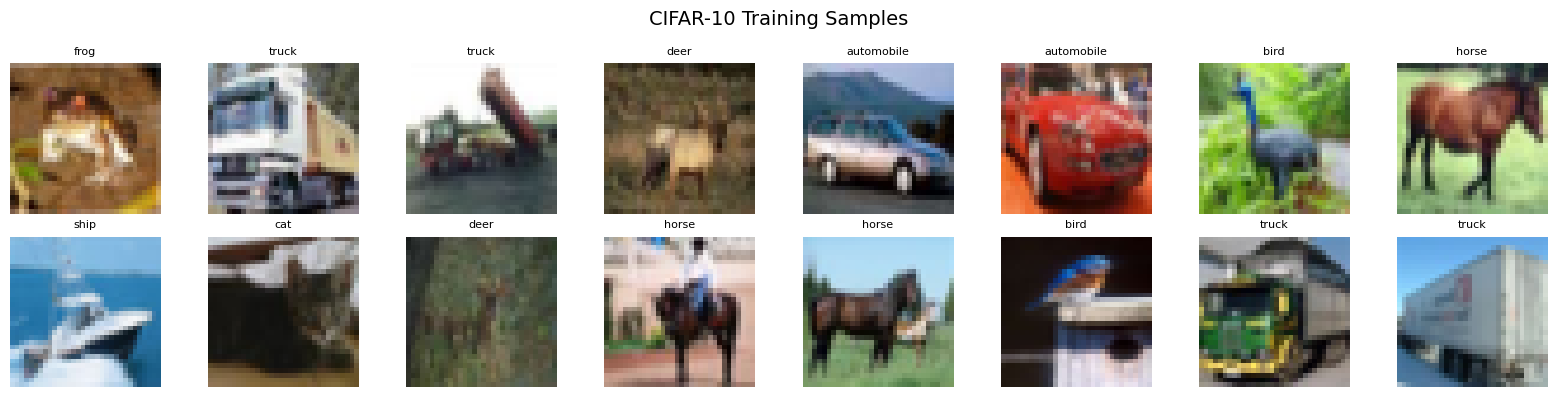

In [4]:
# Load CIFAR-10
transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Lambda(lambda x: x * 2 - 1)  # Scale to [-1, 1]
])

train_dataset = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2, drop_last=True)

# Class names
classes = ('airplane', 'automobile', 'bird', 'cat', 'deer',
           'dog', 'frog', 'horse', 'ship', 'truck')

# Visualize samples
fig, axes = plt.subplots(2, 8, figsize=(16, 4))
for i in range(16):
    img, label = train_dataset[i]
    ax = axes[i // 8, i % 8]
    ax.imshow(((img.permute(1, 2, 0) + 1) / 2).numpy())
    ax.set_title(classes[label], fontsize=8)
    ax.axis('off')
plt.suptitle('CIFAR-10 Training Samples', fontsize=14)
plt.tight_layout()
plt.show()

## 2. Noise Schedule

We implement both **linear** and **cosine** beta schedules.
The cosine schedule (from Improved DDPM) provides better image quality for small images.

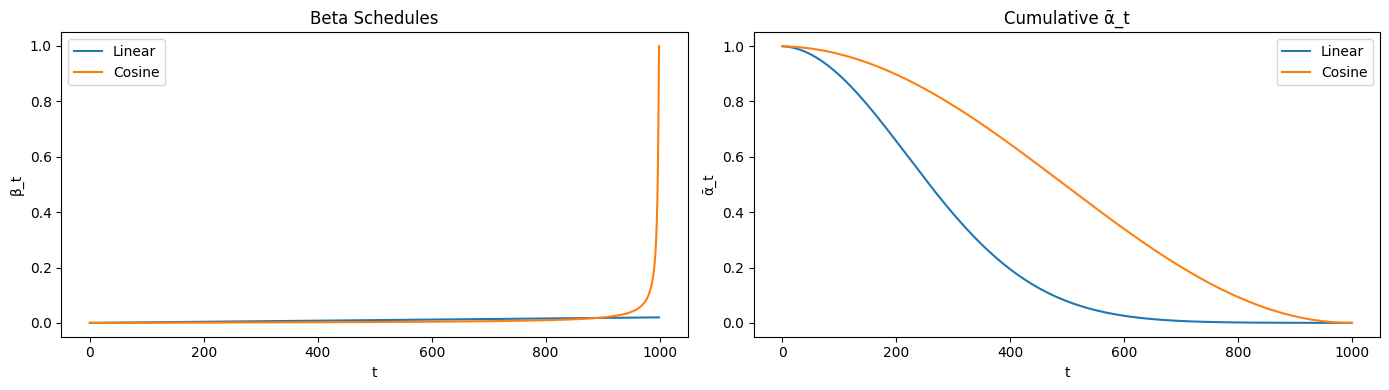

In [5]:
def linear_schedule(T, beta_start=1e-4, beta_end=0.02):
    return torch.linspace(beta_start, beta_end, T)

def cosine_schedule(T, s=0.008):
    """Cosine schedule from 'Improved Denoising Diffusion Probabilistic Models' (Nichol & Dhariwal, 2021)"""
    steps = torch.arange(T + 1, dtype=torch.float64)
    f_t = torch.cos(((steps / T) + s) / (1 + s) * (math.pi / 2)) ** 2
    alphas_bar = f_t / f_t[0]
    betas = 1 - (alphas_bar[1:] / alphas_bar[:-1])
    return torch.clamp(betas, 0.0001, 0.999).float()

# Use linear schedule (standard DDPM)
betas = linear_schedule(T).to(device)
alphas = (1 - betas).to(device)
alphas_bars = torch.cumprod(alphas, dim=0).to(device)

# Plot schedules
lin_betas = linear_schedule(T)
cos_betas = cosine_schedule(T)
lin_ab = torch.cumprod(1 - lin_betas, dim=0)
cos_ab = torch.cumprod(1 - cos_betas, dim=0)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
ax1.plot(lin_betas.numpy(), label='Linear')
ax1.plot(cos_betas.numpy(), label='Cosine')
ax1.set_title('Beta Schedules'); ax1.legend(); ax1.set_xlabel('t'); ax1.set_ylabel('β_t')
ax2.plot(lin_ab.numpy(), label='Linear')
ax2.plot(cos_ab.numpy(), label='Cosine')
ax2.set_title('Cumulative ᾱ_t'); ax2.legend(); ax2.set_xlabel('t'); ax2.set_ylabel('ᾱ_t')
plt.tight_layout(); plt.show()

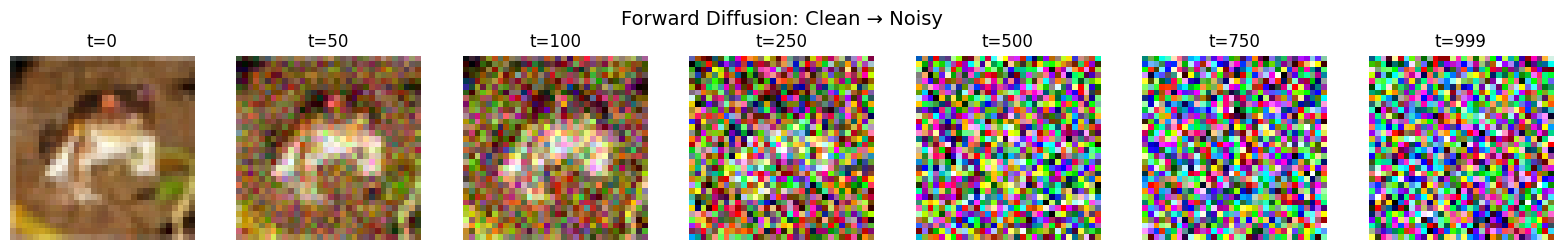

In [6]:
def forward_diffusion(x0, t):
    """Sample x_t from q(x_t | x_0)"""
    noise = torch.randn_like(x0)
    sqrt_ab = torch.sqrt(alphas_bars[t])[:, None, None, None]
    sqrt_1_minus_ab = torch.sqrt(1 - alphas_bars[t])[:, None, None, None]
    return sqrt_ab * x0 + sqrt_1_minus_ab * noise, noise

# Visualize forward diffusion on a CIFAR-10 image
sample_img = train_dataset[0][0].unsqueeze(0).to(device)
timesteps_vis = [0, 50, 100, 250, 500, 750, 999]

fig, axes = plt.subplots(1, len(timesteps_vis), figsize=(16, 2.5))
for i, tv in enumerate(timesteps_vis):
    noisy, _ = forward_diffusion(sample_img, torch.tensor([tv]).to(device))
    img = ((noisy[0].cpu().permute(1, 2, 0) + 1) / 2).clamp(0, 1)
    axes[i].imshow(img); axes[i].set_title(f't={tv}'); axes[i].axis('off')
plt.suptitle('Forward Diffusion: Clean → Noisy', fontsize=14)
plt.tight_layout(); plt.show()

## 3. U-Net Architecture

A deeper U-Net for 32×32 RGB images with:
- **3 encoder levels**: 32→16→8→4 (bottleneck)
- **Channel progression**: 128 → 256 → 256 → 512
- **Self-attention** at 8×8 resolution (bottleneck)
- **GroupNorm(8)** normalization
- **SiLU** activation (Swish)
- **Skip connections** via concatenation

In [7]:
class TimeEmbedding(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim
    def forward(self, t):
        half = self.dim // 2
        freqs = torch.exp(-math.log(10000) * torch.arange(half, device=t.device) / half)
        args = t[:, None] * freqs[None, :]
        return torch.cat((torch.sin(args), torch.cos(args)), dim=-1)

In [8]:
class ResBlock(nn.Module):
    """Residual block with time conditioning and pre-activation."""
    def __init__(self, in_ch, out_ch, time_dim):
        super().__init__()
        self.norm1 = nn.GroupNorm(8, in_ch)
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, padding=1)
        self.norm2 = nn.GroupNorm(8, out_ch)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1)
        self.time_mlp = nn.Linear(time_dim, out_ch)
        self.skip = nn.Conv2d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()

    def forward(self, x, t):
        h = self.conv1(F.silu(self.norm1(x)))
        h = h + self.time_mlp(t)[:, :, None, None]
        h = self.conv2(F.silu(self.norm2(h)))
        return h + self.skip(x)

In [9]:
class SelfAttention(nn.Module):
    """Multi-head self-attention with residual connection."""
    def __init__(self, channels, n_heads=4):
        super().__init__()
        self.norm = nn.GroupNorm(8, channels)
        self.n_heads = n_heads
        self.head_dim = channels // n_heads
        self.qkv = nn.Conv2d(channels, channels * 3, 1)
        self.proj = nn.Conv2d(channels, channels, 1)

    def forward(self, x):
        B, C, H, W = x.shape
        h = self.norm(x)
        qkv = self.qkv(h).reshape(B, 3, self.n_heads, self.head_dim, H * W)
        q, k, v = qkv[:, 0], qkv[:, 1], qkv[:, 2]  # (B, heads, head_dim, HW)
        attn = torch.softmax((q.transpose(-1, -2) @ k) / math.sqrt(self.head_dim), dim=-1)
        h = (attn @ v.transpose(-1, -2)).transpose(-1, -2).reshape(B, C, H, W)
        return x + self.proj(h)

In [10]:
class Downsample(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.conv = nn.Conv2d(channels, channels, 3, stride=2, padding=1)
    def forward(self, x):
        return self.conv(x)

class Upsample(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.conv = nn.Conv2d(channels, channels, 3, padding=1)
    def forward(self, x):
        x = F.interpolate(x, scale_factor=2, mode='nearest')
        return self.conv(x)

In [11]:
class UNet(nn.Module):
    """
    U-Net for CIFAR-10 DDPM.
    Encoder: 32→16→8→4 (bottleneck)
    Channels: 128→256→256→512
    Attention at 8×8 resolution
    """
    def __init__(self, in_ch=3, base_ch=128):
        super().__init__()
        ch = base_ch
        time_dim = ch * 4

        # Time embedding
        self.time_mlp = nn.Sequential(
            TimeEmbedding(ch),
            nn.Linear(ch, time_dim), nn.SiLU(), nn.Linear(time_dim, time_dim)
        )

        # Initial conv
        self.conv_in = nn.Conv2d(in_ch, ch, 3, padding=1)  # 32x32

        # Encoder: 32 → 16 → 8 → 4
        self.enc1_res1 = ResBlock(ch, ch, time_dim)         # 128, 32x32
        self.enc1_res2 = ResBlock(ch, ch, time_dim)
        self.down1 = Downsample(ch)                         # 128, 16x16

        self.enc2_res1 = ResBlock(ch, ch * 2, time_dim)     # 256, 16x16
        self.enc2_res2 = ResBlock(ch * 2, ch * 2, time_dim)
        self.down2 = Downsample(ch * 2)                     # 256, 8x8

        self.enc3_res1 = ResBlock(ch * 2, ch * 2, time_dim) # 256, 8x8
        self.enc3_attn = SelfAttention(ch * 2)              # Attention at 8x8
        self.enc3_res2 = ResBlock(ch * 2, ch * 2, time_dim)
        self.down3 = Downsample(ch * 2)                     # 256, 4x4

        # Bottleneck at 4x4
        self.mid_res1 = ResBlock(ch * 2, ch * 4, time_dim)  # 512, 4x4
        self.mid_attn = SelfAttention(ch * 4)
        self.mid_res2 = ResBlock(ch * 4, ch * 4, time_dim)

        # Decoder: 4 → 8 → 16 → 32
        self.up3 = Upsample(ch * 4)                                # 512, 8x8
        self.dec3_res1 = ResBlock(ch * 4 + ch * 2, ch * 2, time_dim)  # concat skip
        self.dec3_attn = SelfAttention(ch * 2)
        self.dec3_res2 = ResBlock(ch * 2, ch * 2, time_dim)

        self.up2 = Upsample(ch * 2)                                # 256, 16x16
        self.dec2_res1 = ResBlock(ch * 2 + ch * 2, ch * 2, time_dim)
        self.dec2_res2 = ResBlock(ch * 2, ch, time_dim)

        self.up1 = Upsample(ch)                                    # 128, 32x32
        self.dec1_res1 = ResBlock(ch + ch, ch, time_dim)
        self.dec1_res2 = ResBlock(ch, ch, time_dim)

        # Output
        self.norm_out = nn.GroupNorm(8, ch)
        self.conv_out = nn.Conv2d(ch, in_ch, 3, padding=1)

    def forward(self, x, t):
        t = self.time_mlp(t.float())
        x = self.conv_in(x)

        # Encoder
        s1 = self.enc1_res2(self.enc1_res1(x, t), t)
        h = self.down1(s1)

        s2 = self.enc2_res2(self.enc2_res1(h, t), t)
        h = self.down2(s2)

        s3 = self.enc3_res2(self.enc3_attn(self.enc3_res1(h, t)), t)
        h = self.down3(s3)

        # Bottleneck
        h = self.mid_res1(h, t)
        h = self.mid_attn(h)
        h = self.mid_res2(h, t)

        # Decoder
        h = self.up3(h)
        h = torch.cat([h, s3], dim=1)
        h = self.dec3_res1(h, t)
        h = self.dec3_attn(h)
        h = self.dec3_res2(h, t)

        h = self.up2(h)
        h = torch.cat([h, s2], dim=1)
        h = self.dec2_res1(h, t)
        h = self.dec2_res2(h, t)

        h = self.up1(h)
        h = torch.cat([h, s1], dim=1)
        h = self.dec1_res1(h, t)
        h = self.dec1_res2(h, t)

        return self.conv_out(F.silu(self.norm_out(h)))

## 4. EMA and Model Setup

In [12]:
class EMA:
    """Exponential Moving Average for stable sampling."""
    def __init__(self, model, decay=0.9999):
        self.decay = decay
        self.shadow = copy.deepcopy(model)
        self.shadow.eval()
        for p in self.shadow.parameters():
            p.requires_grad_(False)

    @torch.no_grad()
    def update(self, model):
        for s_p, m_p in zip(self.shadow.parameters(), model.parameters()):
            s_p.data.mul_(self.decay).add_(m_p.data, alpha=1 - self.decay)

    def __call__(self, *args, **kwargs):
        return self.shadow(*args, **kwargs)

In [13]:
# Initialize
model = UNet(in_ch=img_channels, base_ch=base_channels).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
ema = EMA(model, decay=ema_decay)

total_params = sum(p.numel() for p in model.parameters())
print(f'Model parameters: {total_params:,}')

Model parameters: 28,452,867


## 5. Training

Train for 80 epochs with gradient clipping and EMA updates.

In [14]:
losses = []

for epoch in range(epochs):
    model.train()
    total_loss = 0

    for x, _ in tqdm(train_loader, desc=f'Epoch {epoch+1}/{epochs}'):
        x = x.to(device)
        t = torch.randint(0, T, (x.shape[0],)).to(device)

        optimizer.zero_grad()
        xt, noise = forward_diffusion(x, t)
        pred = model(xt, t)
        loss = F.mse_loss(pred, noise)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
        optimizer.step()
        ema.update(model)

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    losses.append(avg_loss)
    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f'Epoch {epoch+1}/{epochs} | Loss: {avg_loss:.6f}')

Epoch 1/80: 100%|██████████| 390/390 [03:30<00:00,  1.86it/s]


Epoch 1/80 | Loss: 0.075760


Epoch 10/80: 100%|██████████| 390/390 [03:50<00:00,  1.70it/s]


Epoch 10/80 | Loss: 0.032726


Epoch 20/80: 100%|██████████| 390/390 [03:49<00:00,  1.70it/s]


...

Epoch 60/80 | Loss: 0.030591


Epoch 70/80: 100%|██████████| 390/390 [03:49<00:00,  1.70it/s]


Epoch 70/80 | Loss: 0.030493


Epoch 80/80: 100%|██████████| 390/390 [03:49<00:00,  1.70it/s]

Epoch 80/80 | Loss: 0.030314


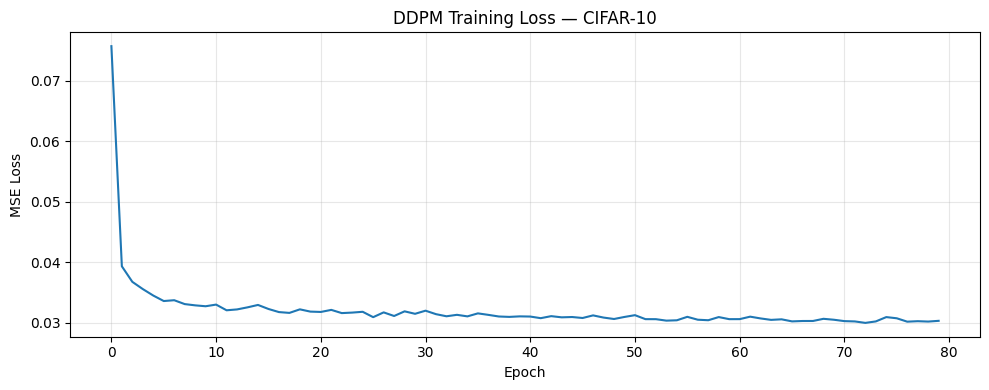

In [15]:
plt.figure(figsize=(10, 4))
plt.plot(losses, linewidth=1.5)
plt.xlabel('Epoch'); plt.ylabel('MSE Loss')
plt.title('DDPM Training Loss — CIFAR-10')
plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

## 6. Sampling — Generate CIFAR-10 Images

Use the EMA model weights for smoother, higher-quality samples.

In [16]:
@torch.no_grad()
def sample_ddpm(model_fn, n=16, return_steps=False):
    """DDPM reverse process sampling."""
    x = torch.randn(n, img_channels, img_size, img_size).to(device)
    steps = []

    for t_val in tqdm(reversed(range(T)), total=T, desc='Sampling'):
        t_batch = torch.full((n,), t_val, device=device)
        eps = model_fn(x, t_batch)

        alpha = alphas[t_val]
        alpha_bar = alphas_bars[t_val]
        beta = betas[t_val]

        z = torch.randn_like(x) if t_val > 0 else torch.zeros_like(x)
        x = (1 / torch.sqrt(alpha)) * (x - (1 - alpha) / torch.sqrt(1 - alpha_bar) * eps) + torch.sqrt(beta) * z

        if return_steps and t_val % (T // 10) == 0:
            steps.append(x.clone())

    if return_steps:
        return x, steps
    return x

Sampling: 100%|██████████| 1000/1000 [00:28<00:00, 35.54it/s]


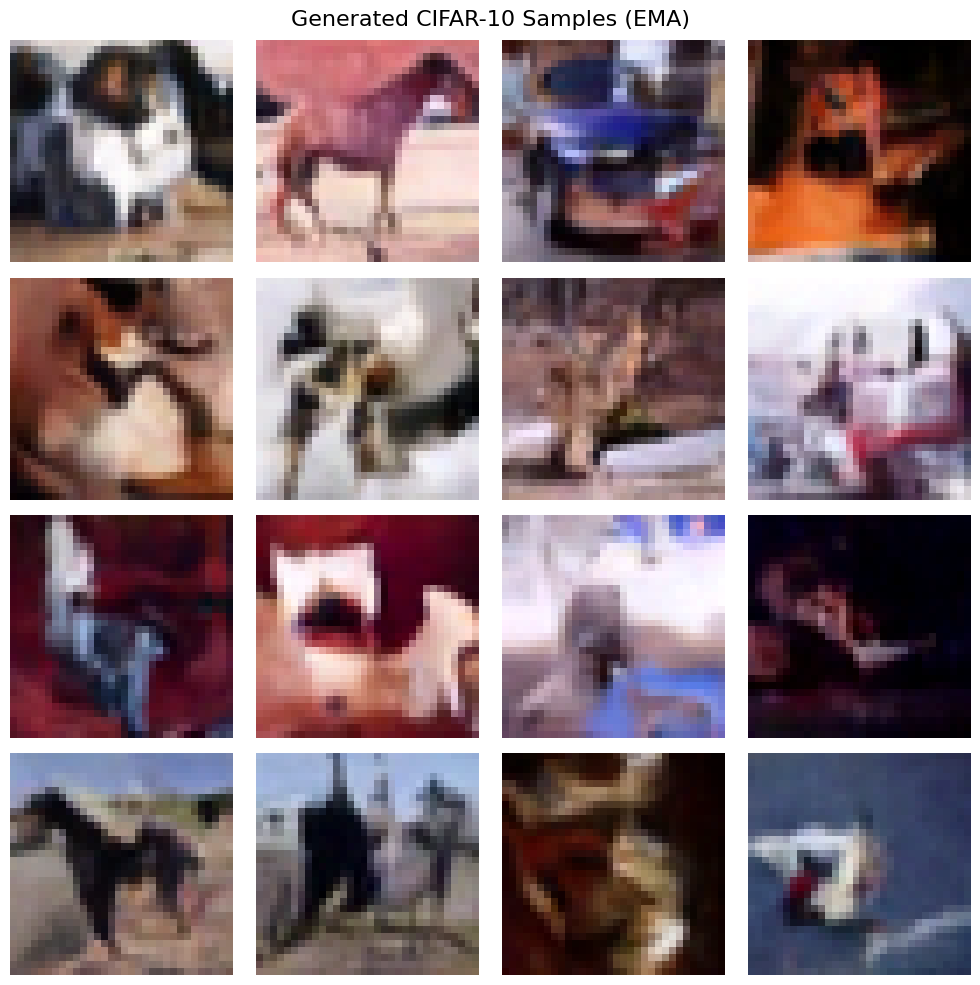

In [17]:
# Generate with EMA model
ema.shadow.eval()
samples = sample_ddpm(ema, n=16)
samples = ((samples + 1) / 2).clamp(0, 1)  # Scale to [0, 1]

fig, axes = plt.subplots(4, 4, figsize=(10, 10))
for i in range(16):
    ax = axes[i // 4, i % 4]
    ax.imshow(samples[i].cpu().permute(1, 2, 0).numpy())
    ax.axis('off')
plt.suptitle('Generated CIFAR-10 Samples (EMA)', fontsize=16)
plt.tight_layout(); plt.show()

## 7. Denoising Process Visualization

Sampling: 100%|██████████| 1000/1000 [00:11<00:00, 90.55it/s]


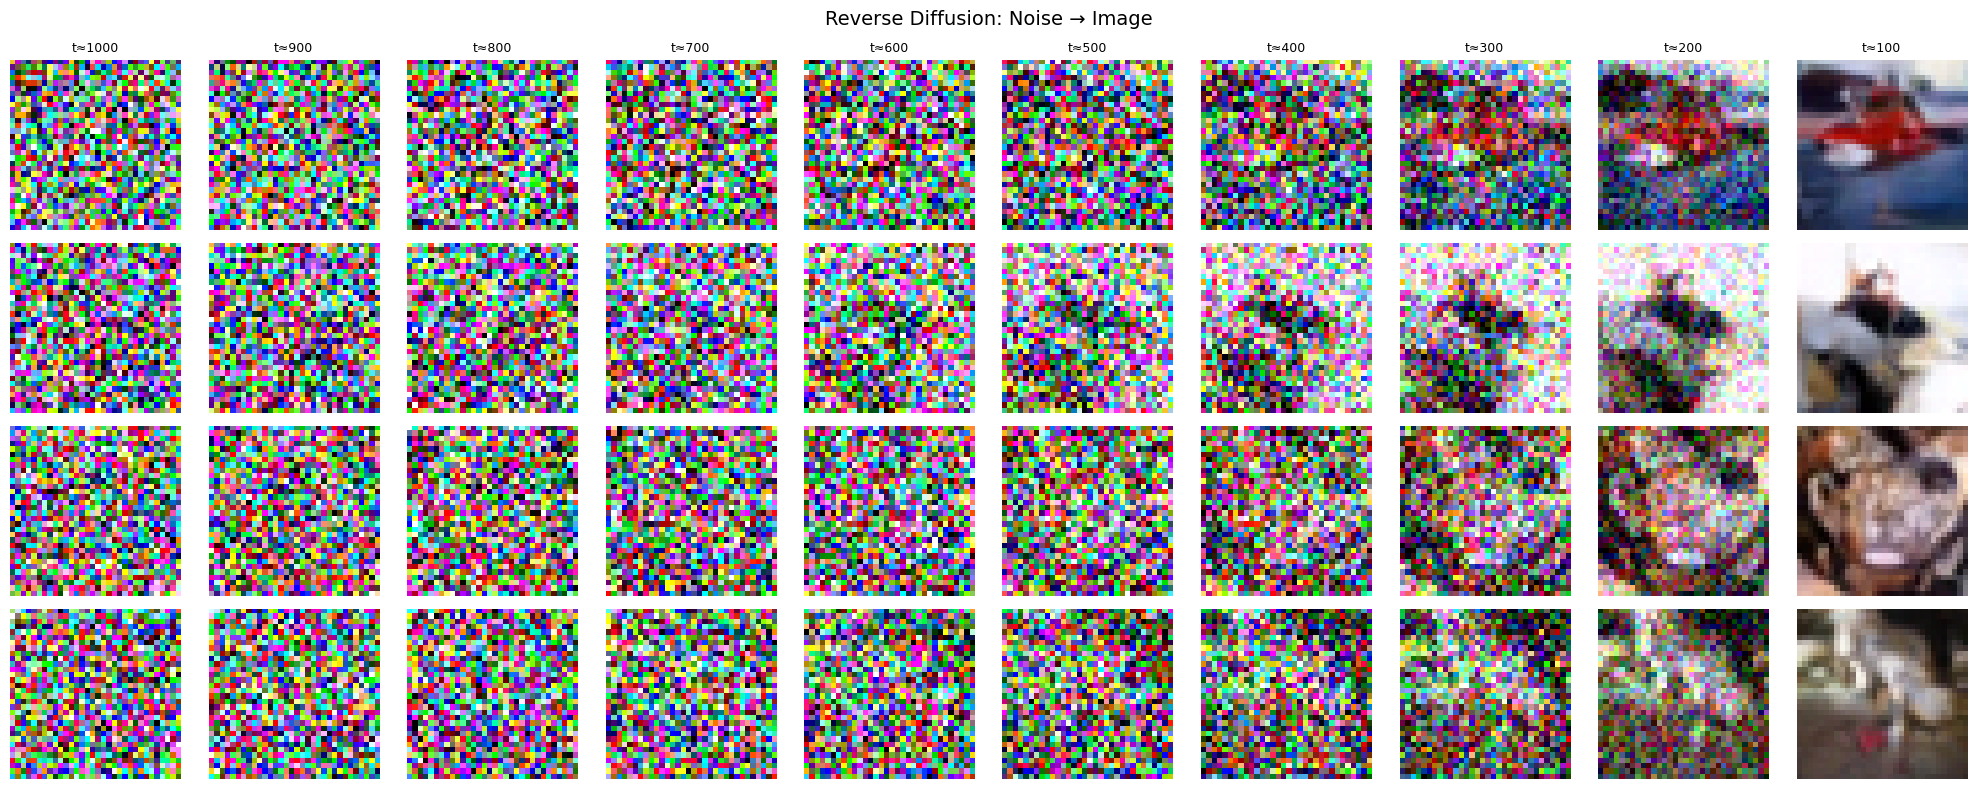

In [18]:
# Visualize the denoising (reverse diffusion) process
ema.shadow.eval()
_, denoise_steps = sample_ddpm(ema, n=4, return_steps=True)

n_steps = len(denoise_steps)
fig, axes = plt.subplots(4, n_steps, figsize=(2 * n_steps, 8))
for row in range(4):
    for col, step_img in enumerate(denoise_steps):
        img = ((step_img[row].cpu().permute(1, 2, 0) + 1) / 2).clamp(0, 1)
        axes[row, col].imshow(img.numpy())
        axes[row, col].axis('off')
        if row == 0:
            axes[row, col].set_title(f't≈{T - col * (T // 10)}', fontsize=9)
plt.suptitle('Reverse Diffusion: Noise → Image', fontsize=14)
plt.tight_layout(); plt.show()

## 8. Large Sample Grid (64 images)

Sampling: 100%|██████████| 1000/1000 [01:38<00:00, 10.16it/s]


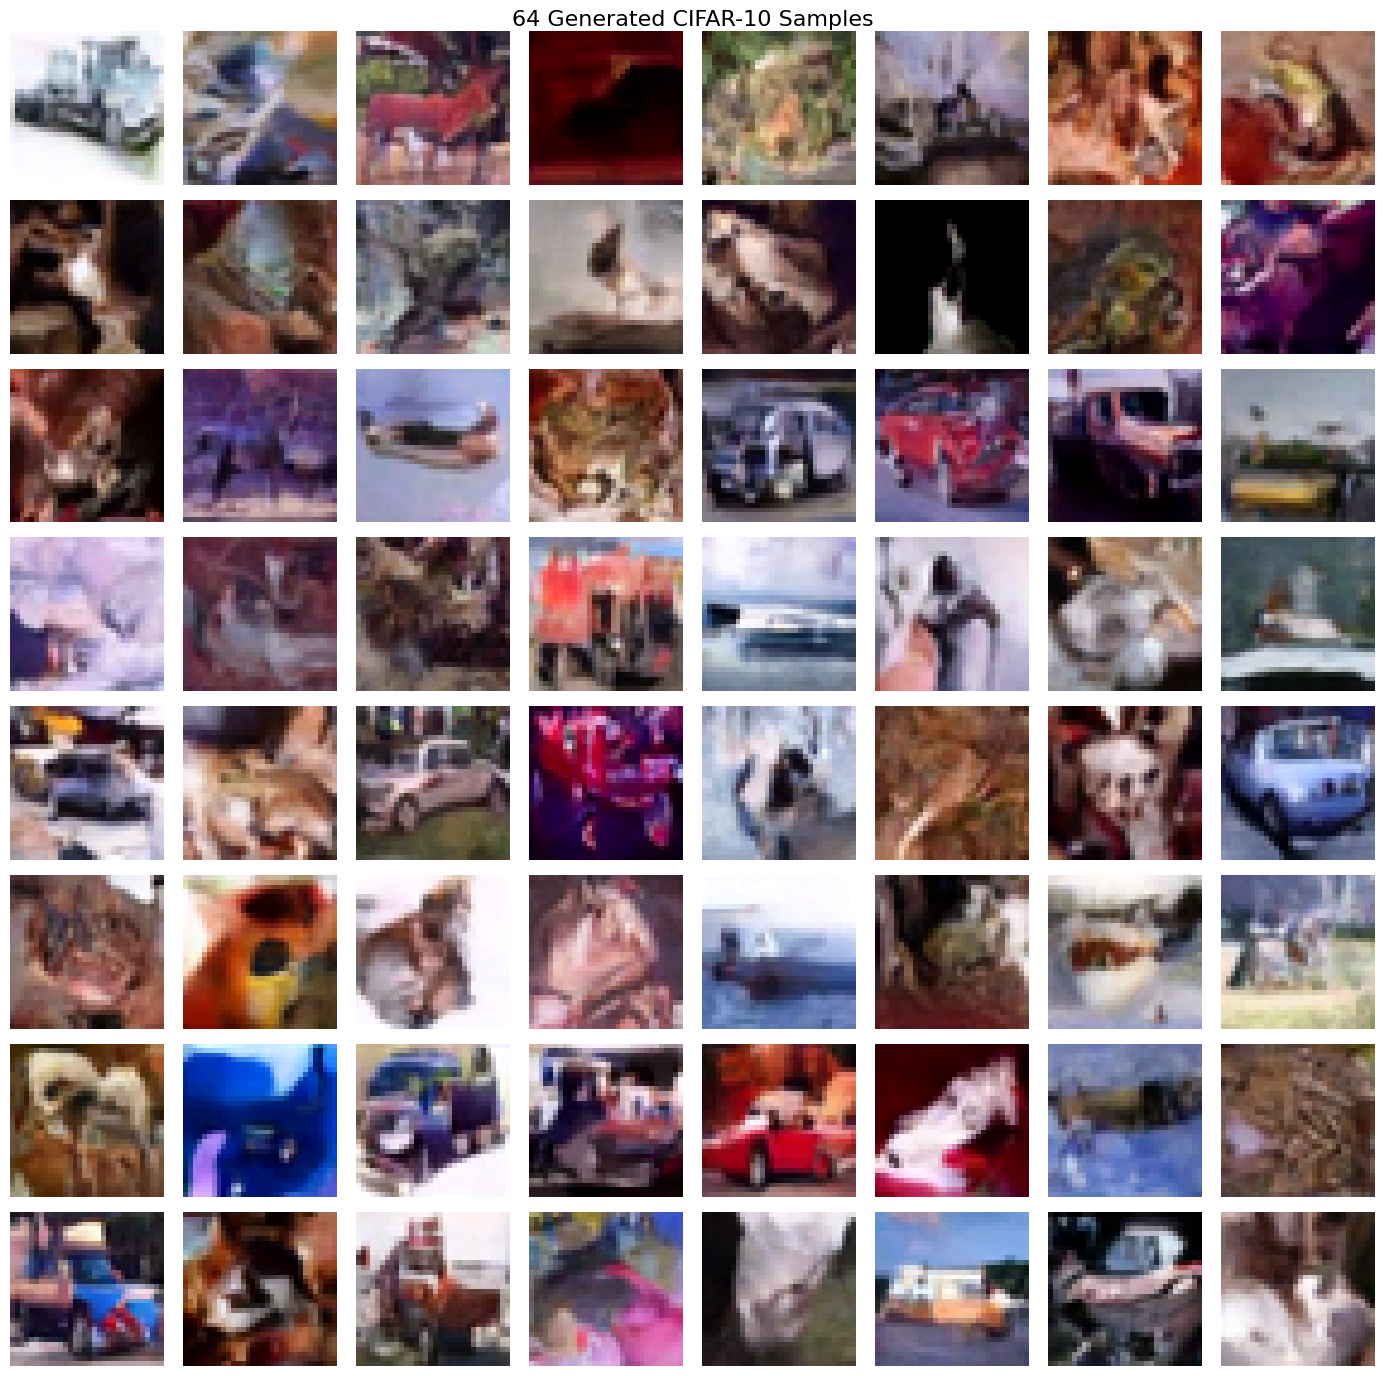

In [19]:
# Generate a larger grid
ema.shadow.eval()
big_samples = sample_ddpm(ema, n=64)
big_samples = ((big_samples + 1) / 2).clamp(0, 1)

fig, axes = plt.subplots(8, 8, figsize=(14, 14))
for i in range(64):
    ax = axes[i // 8, i % 8]
    ax.imshow(big_samples[i].cpu().permute(1, 2, 0).numpy())
    ax.axis('off')
plt.suptitle('64 Generated CIFAR-10 Samples', fontsize=16)
plt.tight_layout(); plt.show()